In [77]:
%pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


1. Imports

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("✅ All packages imported successfully!")
%pip install --upgrade scikit-learn

✅ All packages imported successfully!
Note: you may need to restart the kernel to use updated packages.


2. Configuration


In [79]:
# Path to CSV file
CSV_FILE_PATH = "set A corporate_rating.csv"          

# Column that holds the original credit rating
RATING_COLUMN = "Rating"              

# Derived target column (will be created)
TARGET_COLUMN = "RatingGroup"

# Financial ratio feature columns to use as model inputs
# Leave empty [] to auto-detect all numeric columns (excluding Rating)
FEATURE_COLUMNS = []

# ─────────────────────────────────────────────────────────────
#  RATING GROUP MAPPING
# ─────────────────────────────────────────────────────────────


# Letter-grade Rating 
LETTER_GRADE_MAP = {
    "AAA":  "Investment-High",
    "AA":   "Investment-High",
    "A":    "Investment-High",
    "BBB":  "Investment-Low",
    "BB":   "Speculative",
    "B":    "Speculative",
    "CCC":  "Distressed",
    "CC":   "Distressed",
    "C":    "Distressed",
    "D":    "Distressed",
}

# Load dataset
df = pd.read_csv(CSV_FILE_PATH)

# Create RatingGroup column
df[TARGET_COLUMN] = df[RATING_COLUMN].map(LETTER_GRADE_MAP)

# Verify creation
print(df[[RATING_COLUMN, TARGET_COLUMN]].head())

# ─────────────────────────────────────────────────────────────
#  MODEL SETTINGS
# ─────────────────────────────────────────────────────────────
TEST_SIZE    = 0.30   # 30% held out for testing  (matches KNIME 70/30 split)
RANDOM_STATE = 143    # Reproducibility seed
APPLY_SMOTE  = True   # Set False to skip SMOTE oversampling

print("✅ Configuration loaded.")
print(f"   CSV_FILE_PATH : {CSV_FILE_PATH}")
print(f"   RATING_COLUMN : {RATING_COLUMN}")
print(f"   TARGET_COLUMN : {TARGET_COLUMN}")
print(f"   APPLY_SMOTE   : {APPLY_SMOTE}")
print(f"   TEST_SIZE     : {TEST_SIZE}")

  Rating      RatingGroup
0      A  Investment-High
1    BBB   Investment-Low
2    BBB   Investment-Low
3    BBB   Investment-Low
4    BBB   Investment-Low
✅ Configuration loaded.
   CSV_FILE_PATH : set A corporate_rating.csv
   RATING_COLUMN : Rating
   TARGET_COLUMN : RatingGroup
   APPLY_SMOTE   : True
   TEST_SIZE     : 0.3


3. Load CSV

In [80]:
df = pd.read_csv(CSV_FILE_PATH)

print(f" Dataset loaded   {df.shape[0]:,} rows {df.shape[1]} columns")
print(f"\n Columns ({len(df.columns)}):")
print(list(df.columns))
print(f"\n Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  (none)")
df.head()

 Dataset loaded   2,029 rows 31 columns

 Columns (31):
['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

 Missing values per column:
  (none)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


4. Inspect & Filter Columns

In [81]:
# Auto-detect numeric feature columns if FEATURE_COLUMNS was left empty
if not FEATURE_COLUMNS:
    FEATURE_COLUMNS = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col != RATING_COLUMN
    ]
    print(f"  Auto-detected {len(FEATURE_COLUMNS)} numeric feature columns:")
    print(FEATURE_COLUMNS)

# Keep only feature columns + the rating column
columns_to_keep = FEATURE_COLUMNS + [RATING_COLUMN]
df = df[columns_to_keep].copy()

print(f"\n Retained columns  →  {df.shape[1]} columns, {df.shape[0]:,} rows")
print(f"   Feature columns   :  {len(FEATURE_COLUMNS)}")
print(f"   Target column     :  '{RATING_COLUMN}'")
df.head()

  Auto-detected 25 numeric feature columns:
['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

 Retained columns  →  26 columns, 2,029 rows
   Feature columns   :  25
   Target column     :  'Rating'


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Rating
0,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,0.091514,...,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655,A
1,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,0.104800,...,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846,BBB
2,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,0.075955,...,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510,BBB
3,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,-0.027015,...,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150,BBB
4,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,0.096945,...,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790,BBB


5. Remove Rows with Missing Rating

In [82]:
rows_before = len(df)
df = df.dropna(subset=[RATING_COLUMN])
removed = rows_before - len(df)

print(f"  Removed {removed:,} rows with missing '{RATING_COLUMN}'")
print(f" Remaining rows: {len(df):,}")

  Removed 0 rows with missing 'Rating'
 Remaining rows: 2,029


6. Create RatingGroup

In [83]:
# Detect whether the Rating column contains letter grades or numeric scores
sample_val = df[RATING_COLUMN].dropna().iloc[0]

if isinstance(sample_val, str):
    # ── OPTION A: letter-grade mapping ──────────────────────────────────────
    df[TARGET_COLUMN] = df[RATING_COLUMN].map(LETTER_GRADE_MAP)
    print(" Used letter-grade mapping (LETTER_GRADE_MAP)")

# Warn if any ratings could not be mapped
unmapped = df[TARGET_COLUMN].isnull().sum()
if unmapped > 0:
    print(f"\n  {unmapped} rows could not be mapped — check LETTER_GRADE_MAP or thresholds.")
    print("   Unmapped ratings found:")
    print(df.loc[df[TARGET_COLUMN].isnull(), RATING_COLUMN].unique())
    df = df.dropna(subset=[TARGET_COLUMN])
    print(f"   Rows removed → {len(df):,} remain")

print(f"\n RatingGroup distribution:")
vc = df[TARGET_COLUMN].value_counts()
print(vc)
print(f"\n  Total rows: {len(df):,}")

 Used letter-grade mapping (LETTER_GRADE_MAP)

 RatingGroup distribution:
RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64

  Total rows: 2,029


7. Exploratory Data Analysis (EDA)

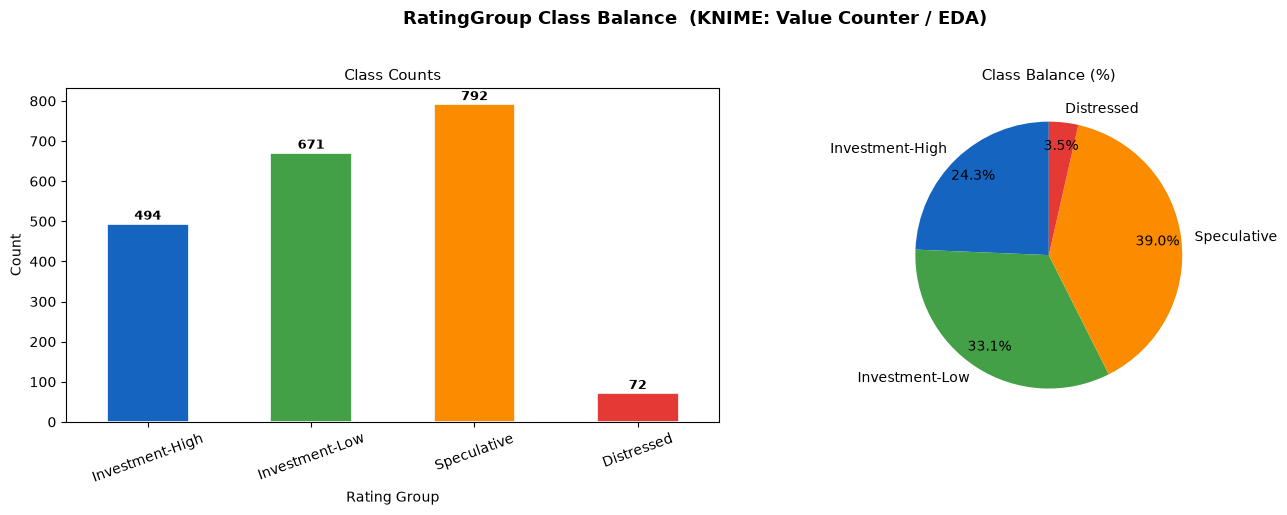

Class distribution saved → class_distribution.png


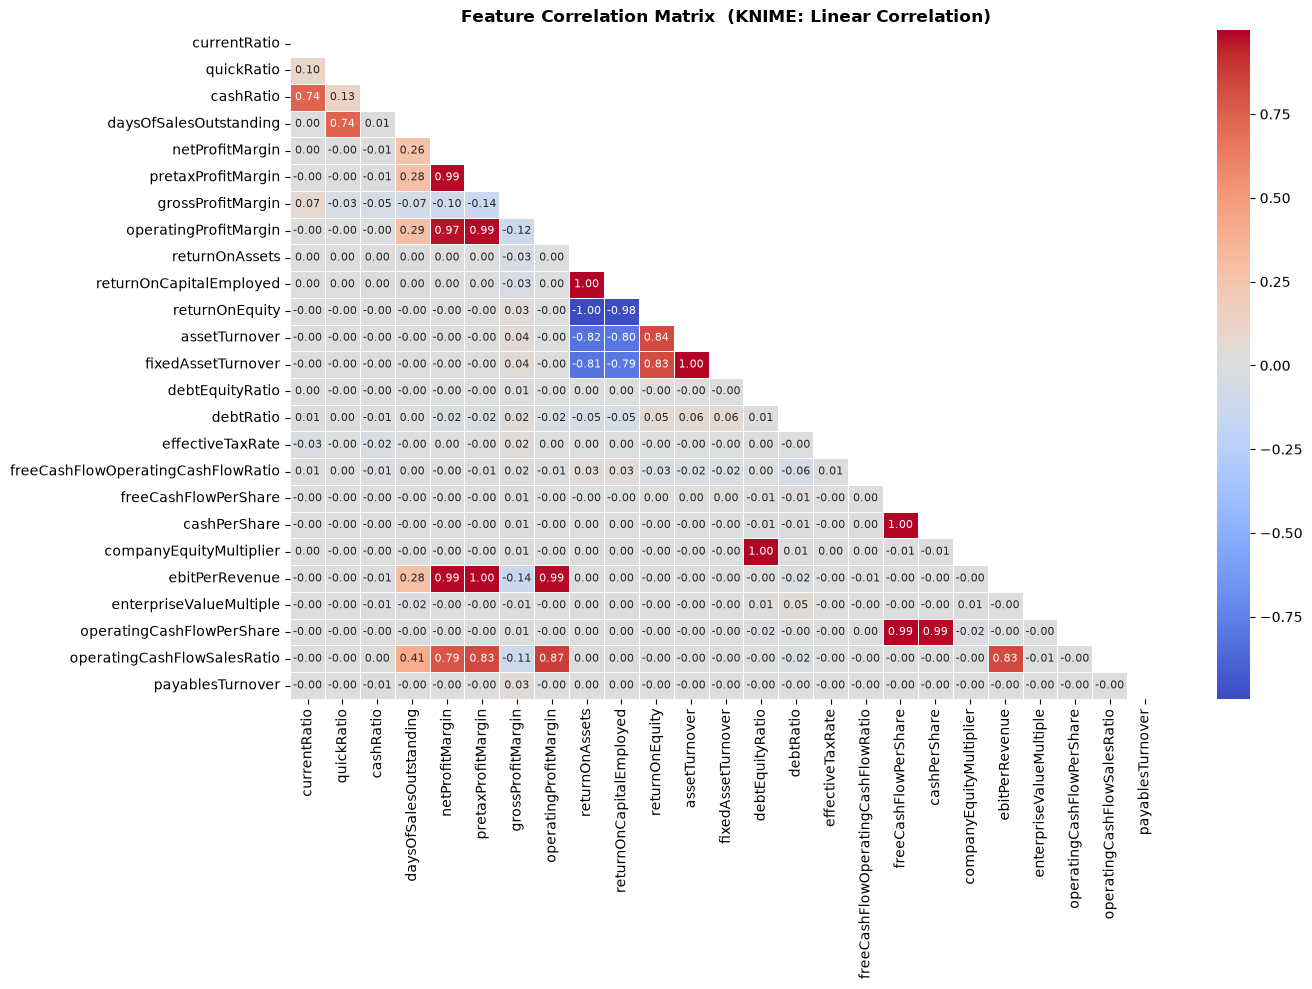

Correlation matrix saved → correlation_matrix.png


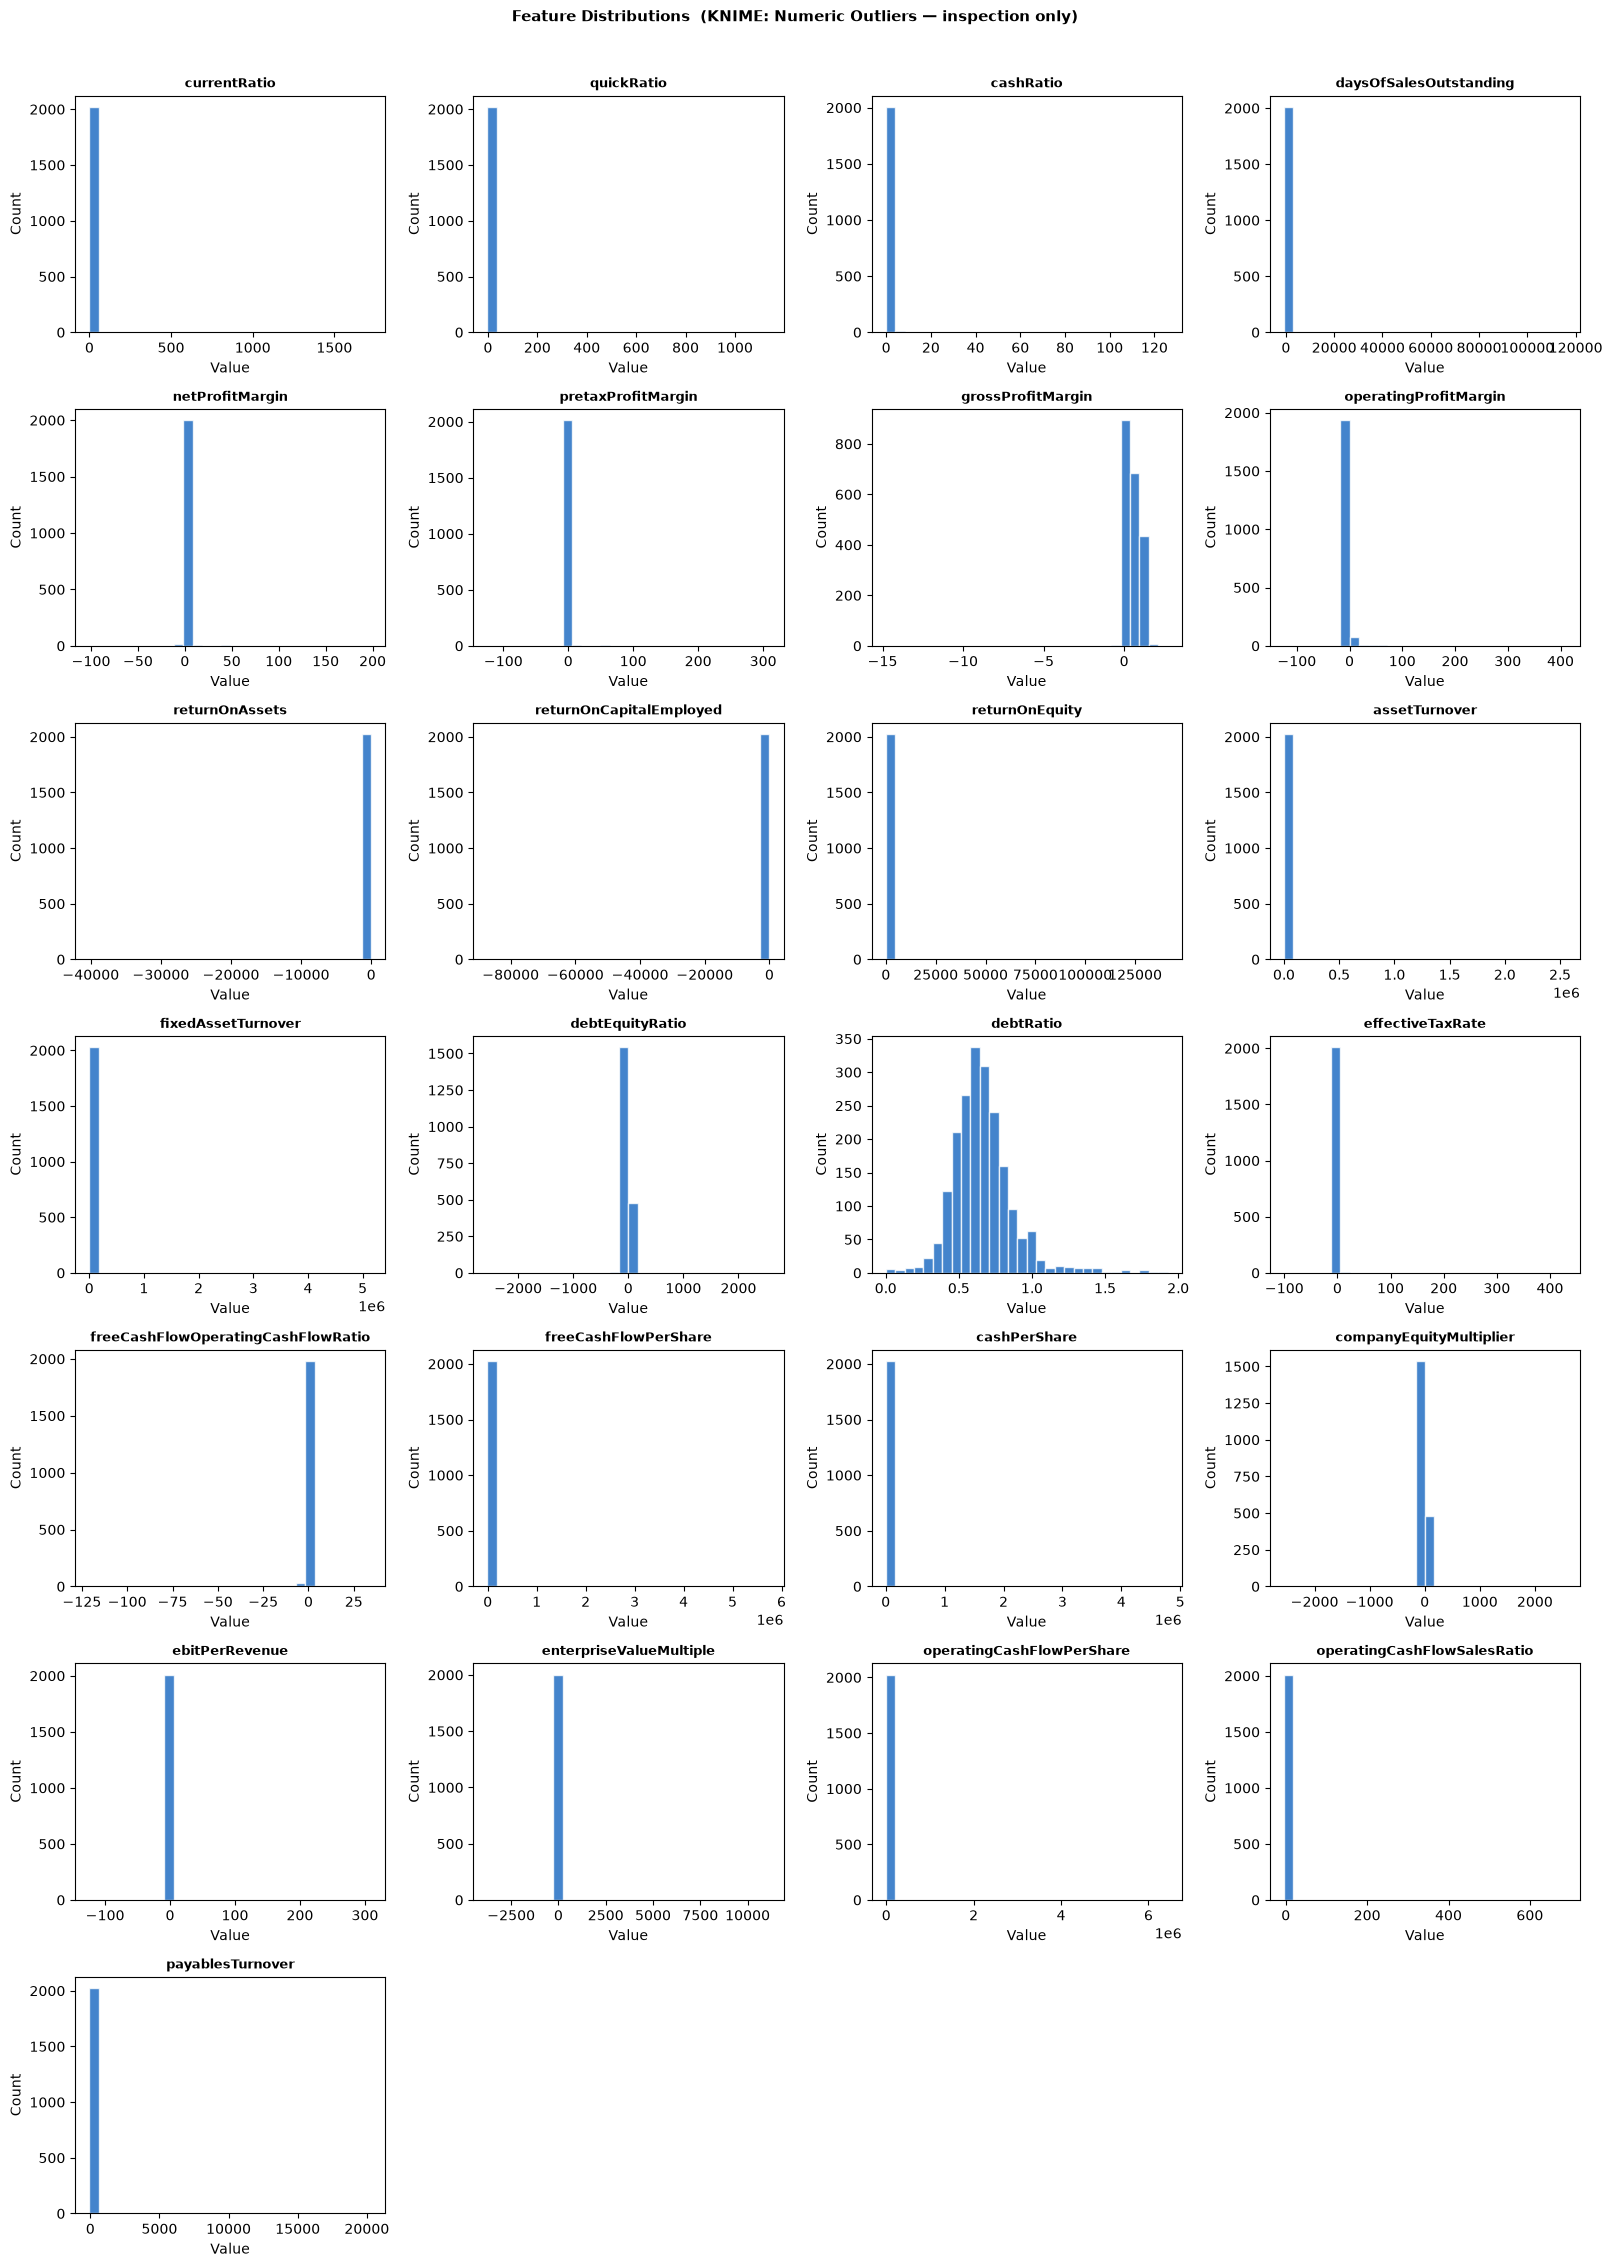

Feature distributions saved → feature_distributions.png


In [84]:
CLASS_ORDER  = ["Investment-High", "Investment-Low", "Speculative", "Distressed"]
CLASS_COLORS = ["#1565C0", "#43A047", "#FB8C00", "#E53935"]

# ── 7a. Class distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RatingGroup Class Balance  (KNIME: Value Counter / EDA)",
             fontsize=13, fontweight="bold", y=1.02)

counts = df[TARGET_COLUMN].value_counts()
ordered_counts = counts.reindex([c for c in CLASS_ORDER if c in counts.index])

bars = ordered_counts.plot(kind="bar", ax=axes[0],
                           color=CLASS_COLORS[:len(ordered_counts)],
                           edgecolor="white", linewidth=1.2)
axes[0].set_title("Class Counts", fontsize=11)
axes[0].set_xlabel("Rating Group"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(ordered_counts):
    axes[0].text(i, v + len(df)*0.005, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

axes[1].pie(ordered_counts, labels=ordered_counts.index,
            autopct="%1.1f%%", colors=CLASS_COLORS[:len(ordered_counts)],
            startangle=90, pctdistance=0.82)
axes[1].set_title("Class Balance (%)", fontsize=11)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution saved → class_distribution.png")

# ── 7b. Feature correlation heatmap ──────────────────────────────────────────
if len(FEATURE_COLUMNS) > 1:
    plt.figure(figsize=(min(14, len(FEATURE_COLUMNS)*1.2 + 2),
                        min(10, len(FEATURE_COLUMNS)*1.0 + 1)))
    corr = df[FEATURE_COLUMNS].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                mask=mask, center=0, linewidths=0.5, annot_kws={"size": 8})
    plt.title("Feature Correlation Matrix  (KNIME: Linear Correlation)",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Correlation matrix saved → correlation_matrix.png")

# ── 7c. Feature distributions ─────────────────────────────────────────────────
n_features = len(FEATURE_COLUMNS)
if n_features > 0:
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4, n_rows * 3.2))
    axes = np.array(axes).flatten()
    for i, col in enumerate(FEATURE_COLUMNS):
        axes[i].hist(df[col].dropna(), bins=30, color="#1565C0",
                     edgecolor="white", alpha=0.8)
        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].set_xlabel("Value"); axes[i].set_ylabel("Count")
    for j in range(i + 1, len(axes)):   # hide unused subplots
        axes[j].set_visible(False)
    plt.suptitle("Feature Distributions  (KNIME: Numeric Outliers — inspection only)",
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Feature distributions saved → feature_distributions.png")

8. Prepare Features & Target

In [85]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

print(f" Features (X): {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"   Target  (y): {y.shape[0]:,} labels")
print(f"\n   Unique classes in y: {sorted(y.unique())}")
print(f"\n   Missing values in X before imputation:")
print(X.isnull().sum())

 Features (X): 2,029 rows × 25 columns
   Target  (y): 2,029 labels

   Unique classes in y: ['Distressed', 'Investment-High', 'Investment-Low', 'Speculative']

   Missing values in X before imputation:
currentRatio                          0
quickRatio                            0
cashRatio                             0
daysOfSalesOutstanding                0
netProfitMargin                       0
pretaxProfitMargin                    0
grossProfitMargin                     0
operatingProfitMargin                 0
returnOnAssets                        0
returnOnCapitalEmployed               0
returnOnEquity                        0
assetTurnover                         0
fixedAssetTurnover                    0
debtEquityRatio                       0
debtRatio                             0
effectiveTaxRate                      0
freeCashFlowOperatingCashFlowRatio    0
freeCashFlowPerShare                  0
cashPerShare                          0
companyEquityMultiplier              

9. Stratified Train-Test Split (70 / 30)

 Split complete  →  Train: 1,420  |  Test: 609

 Training set class distribution:
RatingGroup
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50

 Test set class distribution:
RatingGroup
Speculative        238
Investment-Low     201
Investment-High    148
Distressed          22


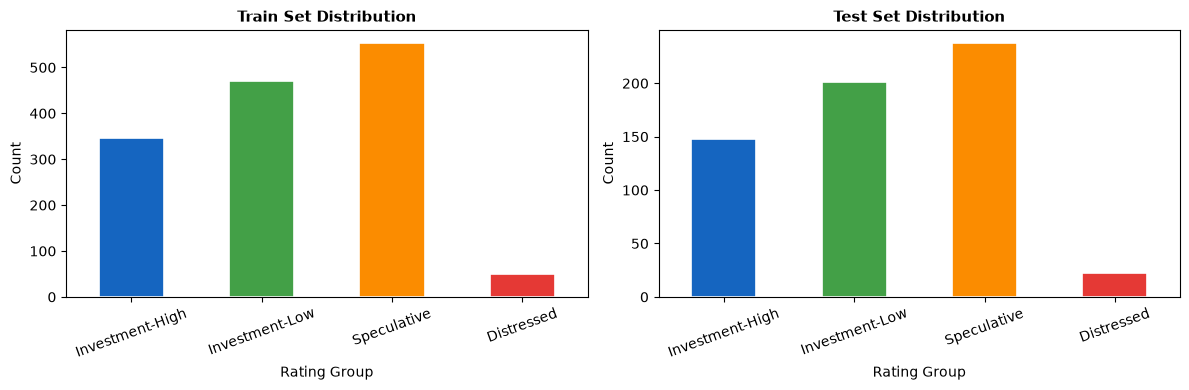

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y          # Preserve class proportions in each split
)

print(f" Split complete  →  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"\n Training set class distribution:")
print(y_train.value_counts().to_string())
print(f"\n Test set class distribution:")
print(y_test.value_counts().to_string())

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, series) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    vc = series.value_counts().reindex([c for c in CLASS_ORDER if c in series.unique()])
    vc.plot(kind="bar", ax=ax, color=CLASS_COLORS[:len(vc)],
            edgecolor="white", linewidth=1.2)
    ax.set_title(f"{label} Set Distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("Rating Group"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

10. Impute Missing Values (Median)

In [87]:
# Fit imputer on TRAIN set only (prevents data leakage)
imputer = SimpleImputer(strategy="median")          # KNIME: fill with median for numeric ratios

X_train_imp = imputer.fit_transform(X_train)        # fit + transform train
X_test_imp  = imputer.transform(X_test)             # transform test with train statistics

X_train_imp = pd.DataFrame(X_train_imp, columns=FEATURE_COLUMNS, index=X_train.index)
X_test_imp  = pd.DataFrame(X_test_imp,  columns=FEATURE_COLUMNS, index=X_test.index)

print(" Median imputation complete")
print(f"   NaN remaining in X_train: {X_train_imp.isnull().sum().sum()}")
print(f"   NaN remaining in X_test : {X_test_imp.isnull().sum().sum()}")
print(f"\n   Median values used (from train):")
for col, med in zip(FEATURE_COLUMNS, imputer.statistics_):
    print(f"     {col:<30} {med:.4f}")

 Median imputation complete
   NaN remaining in X_train: 0
   NaN remaining in X_test : 0

   Median values used (from train):
     currentRatio                   1.4949
     quickRatio                     0.9835
     cashRatio                      0.2971
     daysOfSalesOutstanding         42.7533
     netProfitMargin                0.0643
     pretaxProfitMargin             0.0825
     grossProfitMargin              0.4213
     operatingProfitMargin          0.1078
     returnOnAssets                 0.0448
     returnOnCapitalEmployed        0.0748
     returnOnEquity                 0.1212
     assetTurnover                  0.6980
     fixedAssetTurnover             3.7509
     debtEquityRatio                1.6515
     debtRatio                      0.6386
     effectiveTaxRate               0.3011
     freeCashFlowOperatingCashFlowRatio 0.6447
     freeCashFlowPerShare           2.1569
     cashPerShare                   3.7446
     companyEquityMultiplier        2.6466
     ebi

11. Normalize Features — Z-score

In [88]:
# Fit scaler on TRAIN set only
scaler = StandardScaler()                             # Z-score: (x - mean) / std

X_train_scaled = scaler.fit_transform(X_train_imp)   # fit + transform train
X_test_scaled  = scaler.transform(X_test_imp)        # transform test with train statistics

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLUMNS, index=X_test.index)

print(" Z-score normalization complete")
print(f"   Train mean (should be ≈ 0): {X_train_scaled.mean().mean():.8f}")
print(f"   Train std  (should be ≈ 1): {X_train_scaled.std().mean():.8f}")

 Z-score normalization complete
   Train mean (should be ≈ 0): -0.00000000
   Train std  (should be ≈ 1): 1.00035230


12. SMOTE Oversampling (Training Set Only)

 Class distribution BEFORE SMOTE:
RatingGroup
Speculative        554
Investment-Low     470
Investment-High    346
Distressed          50

 Class distribution AFTER SMOTE:
RatingGroup
Investment-Low     554
Investment-High    554
Speculative        554
Distressed         554

 SMOTE applied: 1,420 → 2,216 training samples


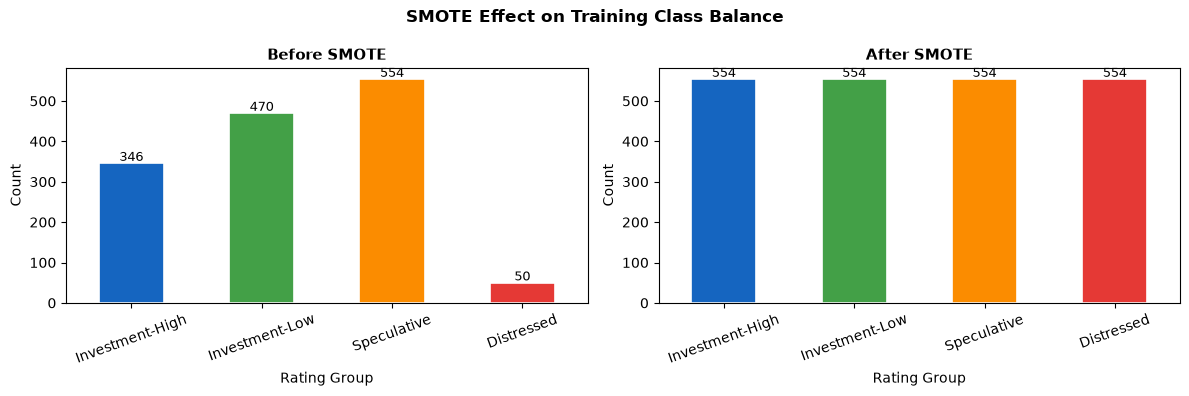

SMOTE balance plot saved → smote_balance.png


In [89]:
print(f" Class distribution BEFORE SMOTE:")
print(y_train.value_counts().to_string())

if APPLY_SMOTE:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

    print(f"\n Class distribution AFTER SMOTE:")
    print(pd.Series(y_train_final).value_counts().to_string())
    print(f"\n SMOTE applied: {len(y_train):,} → {len(y_train_final):,} training samples")

    # Visualise before / after
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (label, series) in zip(axes, [
        ("Before SMOTE", y_train),
        ("After SMOTE",  pd.Series(y_train_final))
    ]):
        vc = series.value_counts().reindex([c for c in CLASS_ORDER if c in series.unique()])
        vc.plot(kind="bar", ax=ax, color=CLASS_COLORS[:len(vc)],
                edgecolor="white", linewidth=1.2)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Rating Group"); ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=20)
        for i, v in enumerate(vc):
            ax.text(i, v + max(vc)*0.01, f"{v:,}", ha="center", fontsize=9)
    plt.suptitle("SMOTE Effect on Training Class Balance", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("smote_balance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("SMOTE balance plot saved → smote_balance.png")
else:
    X_train_final, y_train_final = X_train_scaled, y_train
    print("\n  SMOTE skipped  (APPLY_SMOTE = False)")

13. Train Logistic Regression Model

| KNIME Setting | Value | Python Equivalent |
|---|---|---|
| Solver | Stochastic Average Gradient | `solver='saga'` |
| Multi-class | Softmax (multinomial) | `multi_class='multinomial'` |
| Reference class | Distressed | handled internally by sklearn |
| Max iterations | 100 | `max_iter=1000` (extended for convergence) |

In [90]:
model = LogisticRegression(
    solver      = "saga",           # Stochastic Average Gradient — matches KNIME setting
    max_iter    = 1000,             # Increase if ConvergenceWarning appears
    C           = 1.0,              # Regularization strength  (1/lambda);  tune as needed
    random_state= RANDOM_STATE,
    n_jobs      = -1                # Use all CPU cores
)

model.fit(X_train_final, y_train_final)

print(" Model trained successfully!")
print(f"   Classes       : {list(model.classes_)}")
print(f"   Iterations    : {model.n_iter_[0]}")
print(f"   Features used : {len(FEATURE_COLUMNS)}")

# Print coefficient table
print("\n Model Coefficients  (one row per class):")
coef_df = pd.DataFrame(
    model.coef_,
    index=model.classes_,
    columns=FEATURE_COLUMNS
)
coef_df.index.name = "RatingGroup"
coef_df.round(4)

 Model trained successfully!
   Classes       : ['Distressed', 'Investment-High', 'Investment-Low', 'Speculative']
   Iterations    : 1000
   Features used : 25

 Model Coefficients  (one row per class):


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
RatingGroup,,,,,,,,,,,,,,,,,,,,,
Distressed,0.7295,0.0077,0.6703,0.1620,-1.4359,-1.0702,0.3579,-0.2451,-0.1982,-0.4662,...,-0.0187,-0.1596,-0.0849,0.0967,0.1774,-0.2529,0.0761,-0.1179,-1.0687,0.2465
Investment-High,-1.3837,-0.1193,-0.8693,-0.0555,0.5212,1.2302,0.2603,0.5808,0.0656,0.0696,...,-0.0406,0.2068,-0.0757,-0.1165,-0.1425,0.8144,-0.1876,-0.0183,-1.1356,0.3635
Investment-Low,-0.1462,-0.1643,-0.3135,-0.5190,1.0531,0.7219,-0.3309,0.6535,0.0572,0.0604,...,-0.0978,0.1371,0.3200,0.1201,0.0074,0.5368,-0.1546,-0.2840,-0.8707,-0.2927
Speculative,0.8004,0.2759,0.5125,0.4125,-0.1384,-0.8820,-0.2874,-0.9892,0.0754,0.3363,...,0.1570,-0.1842,-0.1595,-0.1002,-0.0423,-1.0983,0.2661,0.4203,3.0750,-0.3174


14. Predict on Test Set

In [91]:
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Build a results dataframe with predicted class + class probabilities
results_df = pd.DataFrame({
    "Actual"    : y_test.values,
    "Predicted" : y_pred,
    "Match"     : y_test.values == y_pred
}, index=y_test.index)

# Append one probability column per class
for i, cls in enumerate(model.classes_):
    results_df[f"P({cls})"] = y_pred_proba[:, i].round(4)

print(f" Predictions generated for {len(y_pred):,} test samples")
print(f"\n Sample predictions (first 10 rows):")
results_df.head(10)

 Predictions generated for 609 test samples

 Sample predictions (first 10 rows):


,Actual,Predicted,Match,P(Distressed),P(Investment-High),P(Investment-Low),P(Speculative)
108,Investment-High,Investment-High,True,0.1584,0.4304,0.2317,0.1795
635,Investment-Low,Investment-High,False,0.1046,0.4384,0.2940,0.1630
1147,Speculative,Speculative,True,0.1422,0.1958,0.3151,0.3469
1529,Speculative,Speculative,True,0.1446,0.1457,0.2929,0.4168
1180,Investment-Low,Investment-Low,True,0.1915,0.2572,0.3090,0.2422
1505,Distressed,Investment-High,False,0.2982,0.3304,0.1886,0.1828
1724,Investment-Low,Investment-High,False,0.2355,0.3943,0.2161,0.1541
421,Investment-Low,Investment-Low,True,0.2137,0.2389,0.2937,0.2537
756,Investment-High,Distressed,False,0.2595,0.2413,0.2581,0.2411
519,Speculative,Investment-High,False,0.1758,0.3870,0.2542,0.1830


15. Evaluate Model

In [92]:
accuracy        = accuracy_score(y_test, y_pred)
f1_macro        = f1_score(y_test, y_pred, average="macro")
f1_weighted     = f1_score(y_test, y_pred, average="weighted")
f1_per_class    = f1_score(y_test, y_pred, average=None, labels=model.classes_)

# ── Print summary ──────────────────────────────────────────────────────────────
print("=" * 58)
print("          MODEL EVALUATION RESULTS")
print("=" * 58)
print(f"  Accuracy              :  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1-Score (Macro)      :  {f1_macro:.4f}")
print(f"  F1-Score (Weighted)   :  {f1_weighted:.4f}")
print("-" * 58)
print("  Per-class F1-Score:")
for cls, f1 in zip(model.classes_, f1_per_class):
    bar = "█" * int(f1 * 20)
    print(f"    {cls:<20} {f1:.4f}  {bar}")
print("=" * 58)

print("\n Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=model.classes_))

          MODEL EVALUATION RESULTS
  Accuracy              :  0.3908  (39.08%)
  F1-Score (Macro)      :  0.3585
  F1-Score (Weighted)   :  0.4002
----------------------------------------------------------
  Per-class F1-Score:
    Distressed           0.2286  ████
    Investment-High      0.3515  ███████
    Investment-Low       0.4470  ████████
    Speculative          0.4069  ████████

 Full Classification Report:
                 precision    recall  f1-score   support

     Distressed       0.14      0.55      0.23        22
Investment-High       0.32      0.39      0.35       148
 Investment-Low       0.42      0.48      0.45       201
    Speculative       0.64      0.30      0.41       238

       accuracy                           0.39       609
      macro avg       0.38      0.43      0.36       609
   weighted avg       0.47      0.39      0.40       609



16. Confusion Matrix Visualization

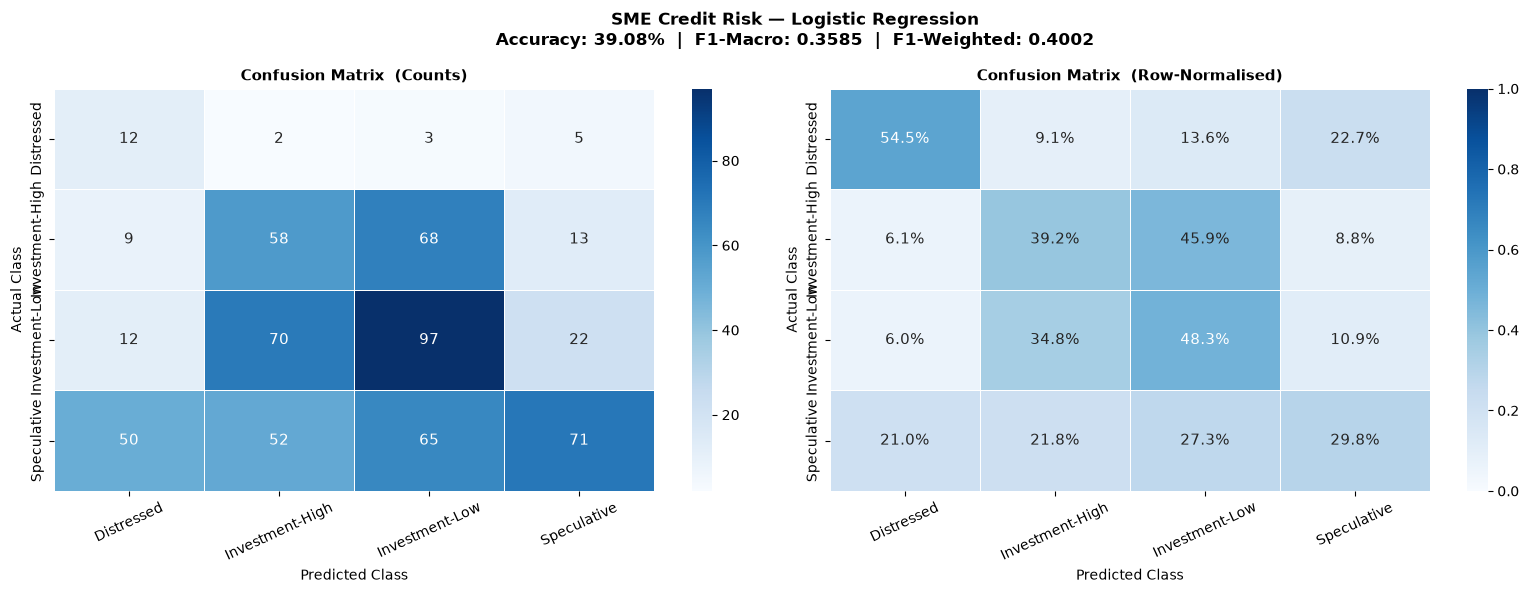

Confusion matrix saved → confusion_matrix.png


In [93]:
cm      = confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]   # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"SME Credit Risk — Logistic Regression\n"
    f"Accuracy: {accuracy:.2%}  |  F1-Macro: {f1_macro:.4f}  |  F1-Weighted: {f1_weighted:.4f}",
    fontsize=12, fontweight="bold"
)

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_,
            linewidths=0.6, linecolor="white", ax=axes[0], annot_kws={"size": 11})
axes[0].set_title("Confusion Matrix  (Counts)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted Class", fontsize=10)
axes[0].set_ylabel("Actual Class", fontsize=10)
axes[0].tick_params(axis="x", rotation=25)

# Normalised percentages
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_,
            linewidths=0.6, linecolor="white", ax=axes[1],
            vmin=0, vmax=1, annot_kws={"size": 11})
axes[1].set_title("Confusion Matrix  (Row-Normalised)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predicted Class", fontsize=10)
axes[1].set_ylabel("Actual Class", fontsize=10)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved → confusion_matrix.png")

17. Feature Importance (Coefficients per Class)

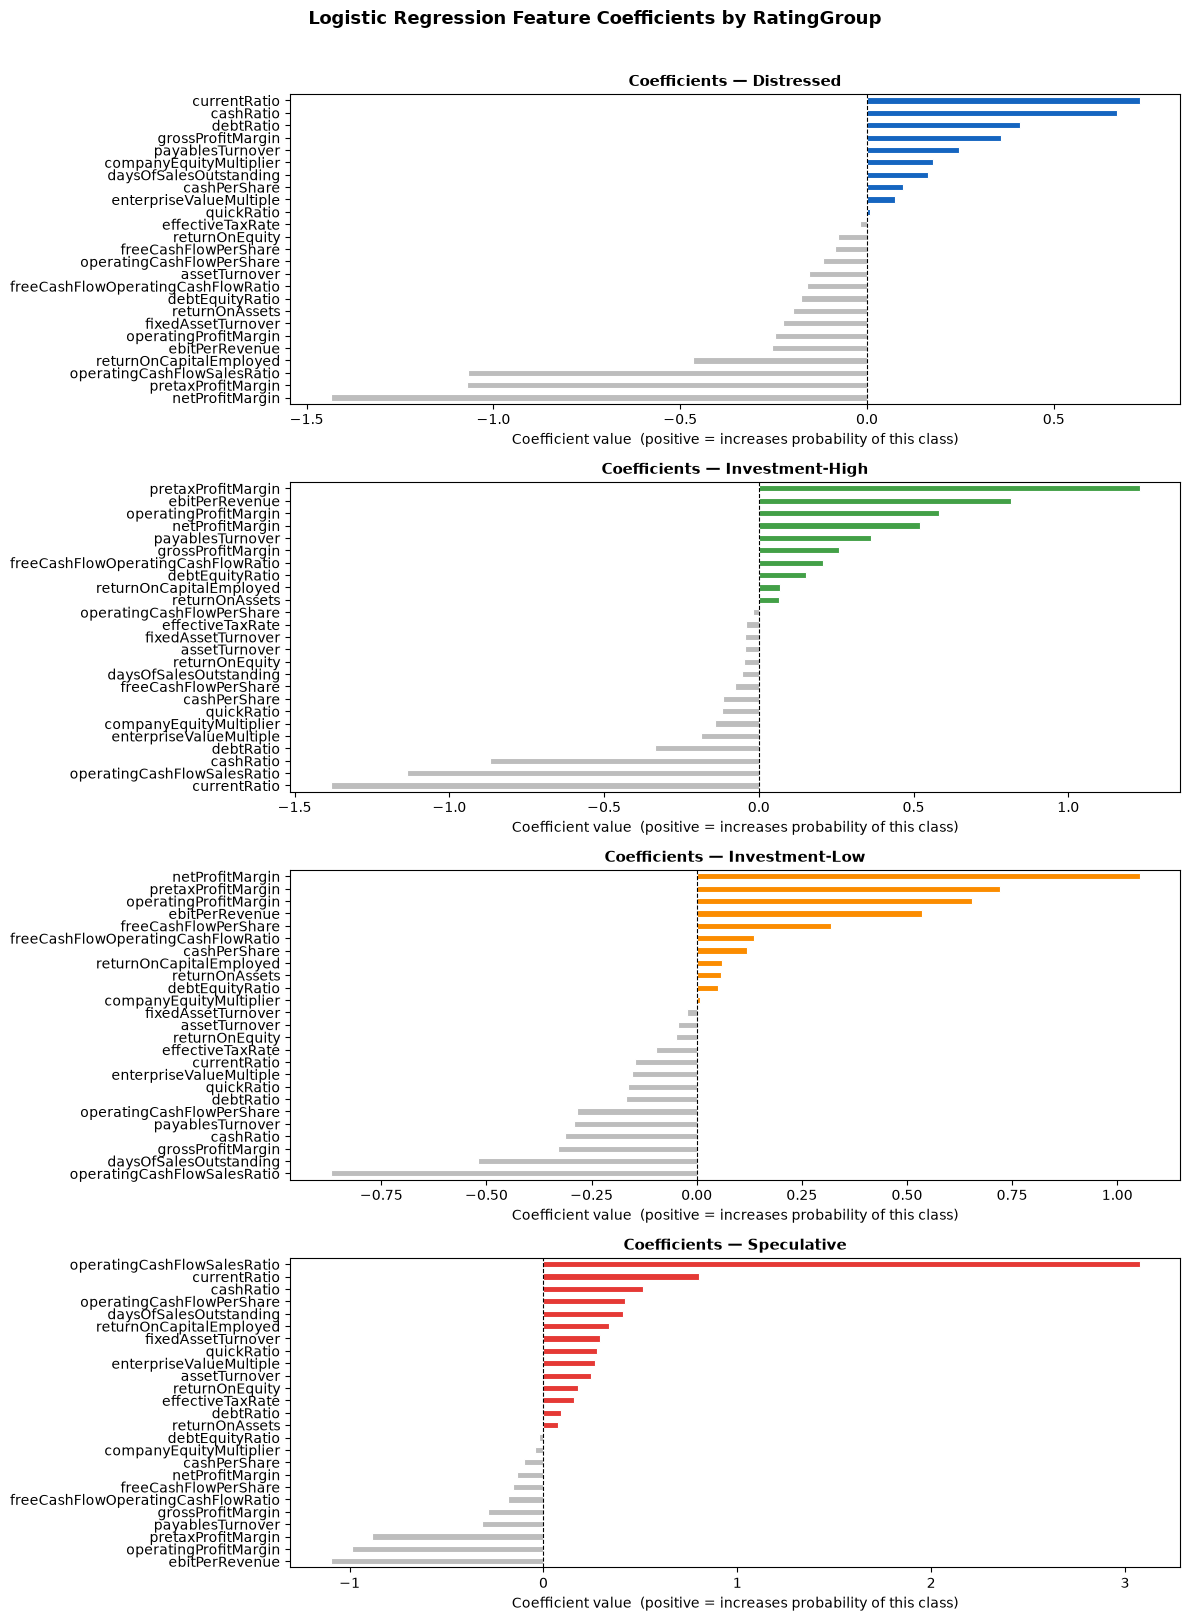

Coefficient plot saved → feature_coefficients.png


In [94]:
n_classes = len(model.classes_)
fig, axes = plt.subplots(n_classes, 1, figsize=(12, 4 * n_classes))
if n_classes == 1:
    axes = [axes]

for ax, cls, color in zip(axes, model.classes_, CLASS_COLORS):
    coefs = pd.Series(model.coef_[model.classes_.tolist().index(cls)],
                      index=FEATURE_COLUMNS).sort_values()
    bar_colors = [color if v >= 0 else "#BDBDBD" for v in coefs]
    coefs.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="white", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Coefficients — {cls}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Coefficient value  (positive = increases probability of this class)")

plt.suptitle("Logistic Regression Feature Coefficients by RatingGroup",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Coefficient plot saved → feature_coefficients.png")

## 18. Summary

| Step | Node (KNIME) | Python Implementation | Status |
|------|-------------|----------------------|--------|
| 1 | CSV Reader | `pd.read_csv()` | ✅ |
| 2 | Column Filter | DataFrame selection | ✅ |
| 3 | Row Filter | `dropna(subset=[RATING_COLUMN])` | ✅ |
| 4 | Domain Calculator + Rule Engine | `map()` / `apply()` | ✅ |
| 5 | Value Counter / EDA | matplotlib + seaborn | ✅ |
| 6 | Missing Value (median) | `SimpleImputer(strategy='median')` | ✅ |
| 7 | Normalizer (Z-score) | `StandardScaler` | ✅ |
| 8 | Table Partitioner (70/30) | `train_test_split(stratify=y)` | ✅ |
| 9 | SMOTE | `imblearn.SMOTE` | ✅ |
| 10 | Logistic Regression Learner | `LogisticRegression(solver='saga')` | ✅ |
| 11 | Logistic Regression Predictor | `model.predict()` | ✅ |
| 12 | Scorer | `accuracy_score`, `f1_score`, `confusion_matrix` | ✅ |

**Generated output files:**
- `class_distribution.png` — class balance bar & pie chart
- `correlation_matrix.png` — feature correlation heatmap
- `feature_distributions.png` — histogram per feature
- `smote_balance.png` — before/after SMOTE comparison
- `confusion_matrix.png` — raw count & normalised confusion matrices
- `feature_coefficients.png` — model coefficients per class

In [95]:
print("=" * 55)
print(" KNIME → Python Workflow Replication Complete! ")
print("=" * 55)
print(f"  Final Accuracy      : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1-Score (Macro)    : {f1_macro:.4f}")
print(f"  F1-Score (Weighted) : {f1_weighted:.4f}")
print("=" * 55)
print("\n  Files saved in the current working directory:")
import os
for fname in ["class_distribution.png", "correlation_matrix.png",
              "feature_distributions.png", "smote_balance.png",
              "confusion_matrix.png", "feature_coefficients.png"]:
    exists = "✅" if os.path.exists(fname) else "⬜ (not generated)"
    print(f"    {exists}  {fname}")

 KNIME → Python Workflow Replication Complete! 
  Final Accuracy      : 0.3908  (39.08%)
  F1-Score (Macro)    : 0.3585
  F1-Score (Weighted) : 0.4002

  Files saved in the current working directory:
    ✅  class_distribution.png
    ✅  correlation_matrix.png
    ✅  feature_distributions.png
    ✅  smote_balance.png
    ✅  confusion_matrix.png
    ✅  feature_coefficients.png


SHAP INTEGRATION

In [99]:
# Import required libraries
%pip install shap
%pip install --upgrade scikit-learn
%pip install imbalanced-learn
%pip install --upgrade imbalanced-learn
%pip install --upgrade shap
%pip install --upgrade matplotlib seaborn
%pip install --upgrade shap numpy pandas

import shap
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("set A corporate_rating.csv")

# Map original ratings to grouped categories
LETTER_GRADE_MAP = {
    "AAA": "Investment-High",
    "AA": "Investment-High",
    "A": "Investment-High",
    "BBB": "Investment-Low",
    "BB": "Speculative",
    "B": "Speculative",
    "CCC": "Distressed",
    "CC": "Distressed",
    "C": "Distressed",
    "D": "Distressed"
}

df['RatingGroup'] = df['Rating'].map(LETTER_GRADE_MAP)

# Select features and target
X = df[['currentRatio','quickRatio','cashRatio','daysOfSalesOutstanding','netProfitMargin','pretaxProfitMargin']]
y = df['RatingGroup']

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split + optional SMOTE for train set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.3, random_state=143)
sm = SMOTE(random_state=143)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Train Logistic Regression
model = LogisticRegression(
    solver='saga',           # Matches KNIME solver
    multi_class='multinomial',
    max_iter=1000,
    C=1.0,
    random_state=143
)
model.fit(X_train_res, y_train_res)

# Predict & evaluate
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# SHAP explanation
explainer = shap.Explainer(model, X_train_res)
shap_values = explainer(X_test)

# Visualizations
shap.summary_plot(shap_values, X, plot_type="bar")          # Global importance
shap.plots.waterfall(shap_values[0])                        # Local explanation for first company
shap.plots.bar(shap_values)                                 # Mean SHAP per class

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
    --------------------------------------- 0.3/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 2.6 MB/s eta 0:00:05
   ------- -------------------------------- 2.4/12.3 MB 4.1 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.3 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.3 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 12.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------------------------------- - 9.4/9.8 MB 45.2 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 40.6 MB/s eta 0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.1.3

   ---------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'